# 04 — Near-Field (Focused) Beamforming

Notebooks 01–03 assume far-field (plane-wave) propagation.  That assumption breaks down
when the source is within the Fraunhofer distance `r_FF = 2D²/λ`.

For a 300 mm aperture at 4 kHz (λ = 86 mm): `r_FF ≈ 2.1 m`.  At typical operating
distances (0.5–2 m) the array is firmly in the near field.

This notebook:
1. Quantifies when far-field fails (criterion plots)
2. Implements a spherical-wave (focused) steering vector
3. Compares far-field vs. near-field D&S on a near-field source
4. Produces a 2D focused map (range × azimuth) — the actual acoustic camera image
5. Benchmarks D&S / MVDR / MUSIC with near-field steering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MAX  = 0.150
R_MIN  = 0.025
N_SNAP = 256
rng    = np.random.default_rng(42)


def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
D_APERTURE = 2 * R_MAX   # 300 mm
print(f"Array: {N_MICS} mics, aperture D = {D_APERTURE*1000:.0f} mm")

Array: 96 mics, aperture D = 300 mm


## Far-Field Validity Criterion

The Fraunhofer (far-field) distance for aperture diameter D:

$$r_{FF} = \frac{2D^2}{\lambda}$$

A source must be beyond `r_FF` for the plane-wave approximation to hold to within λ/16
phase error across the aperture.

 Freq (Hz)    λ (mm)    r_FF (m)
----------------------------------
       200    1715.0        0.10
       500     686.0        0.26
      1000     343.0        0.52
      2000     171.5        1.05
      4000      85.8        2.10
      8000      42.9        4.20


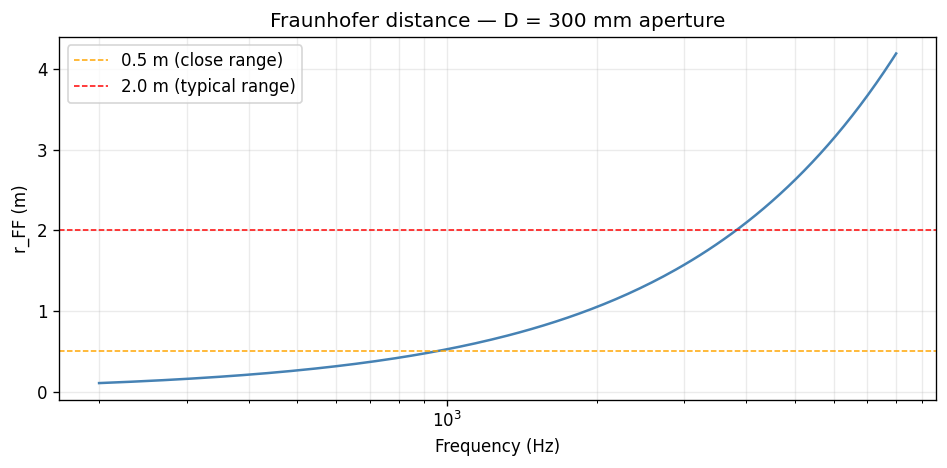


At r < r_FF, plane-wave steering gives phase errors > λ/16 across the aperture.


In [2]:
freqs = np.array([200, 500, 1000, 2000, 4000, 8000])
r_ff  = 2 * D_APERTURE**2 / (C / freqs)

print(f"{'Freq (Hz)':>10}  {'λ (mm)':>8}  {'r_FF (m)':>10}")
print("-" * 34)
for f, r in zip(freqs, r_ff):
    lam = C / f * 1000
    print(f"{f:>10}  {lam:>8.1f}  {r:>10.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
f_plot = np.logspace(np.log10(200), np.log10(8000), 200)
ax.plot(f_plot, 2 * D_APERTURE**2 / (C / f_plot), color='steelblue')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.9, label='0.5 m (close range)')
ax.axhline(2.0, color='red',    linestyle='--', linewidth=0.9, label='2.0 m (typical range)')
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('r_FF (m)')
ax.set_title(f'Fraunhofer distance — D = {D_APERTURE*1000:.0f} mm aperture')
ax.legend()
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.savefig('nf_criterion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAt r < r_FF, plane-wave steering gives phase errors > λ/16 across the aperture.")

## Steering Vectors

**Far-field** (plane wave, elevation = 0):

$$h_n^{FF}(\theta, f) = \frac{1}{\sqrt{N}} \exp\!\left( j \frac{2\pi f}{c} \sin(\theta)\, x_n \right)$$

Only the x-component of the mic position enters; wavefronts are planar.

**Near-field** (spherical wave):

$$h_n^{NF}(\mathbf{r}_s, f) \propto \exp\!\left( -j \frac{2\pi f}{c} d_n \right)$$

where $d_n = |\mathbf{r}_s - \mathbf{r}_n|$ is the Euclidean distance from mic $n$ to the
source.  The amplitude factor $1/d_n$ is included before normalisation so that mics
farther from the source receive appropriate down-weighting.

Coordinate system: array in the *xy*-plane ($z = 0$); boresight along $+z$.
Source at azimuth $\theta$, range $r$:
$$\mathbf{r}_s = \bigl(r\sin\theta,\; 0,\; r\cos\theta\bigr)$$

In [3]:
# ── Far-field steering vector (plane wave) ────────────────────────────────────
def sv_ff(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


# ── Near-field steering vector (spherical wave) ───────────────────────────────
def sv_nf(x, y, src_xyz, freq):
    xs, ys, zs = src_xyz
    d = np.sqrt((xs - x)**2 + (ys - y)**2 + zs**2)
    h = np.exp(-1j * 2 * np.pi * freq / C * d) / d
    return h / np.linalg.norm(h)


def az_to_xyz(az_deg, range_m):
    # Convert (azimuth, range) to Cartesian source position.
    az = np.radians(az_deg)
    return (range_m * np.sin(az), 0.0, range_m * np.cos(az))


# ── Near-field CSM generator ─────────────────────────────────────────────────
def make_csm_nf(x, y, sources, freq, snr_db=20, n_snap=N_SNAP):
    # sources: list of ((xs, ys, zs), power_linear)
    # Noise power referenced to the loudest source at the given SNR.
    N = len(x)
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for xyz, power in sources:
            h = sv_nf(x, y, xyz, freq)
            s = rng.standard_normal() + 1j * rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise = rng.standard_normal(N) + 1j * rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def to_db(m, floor_db=-40):
    with np.errstate(divide='ignore'):
        db = 10 * np.log10(m / m.max())
    return np.clip(db, floor_db, 0)

## 1D Comparison — Far-Field vs. Near-Field Beamforming

Source at **r = 1 m, az = 20°, f = 4 kHz** (well inside the near field: r_FF ≈ 2.1 m).

The CSM is built with spherical-wave steering vectors.  We then scan with:
- Far-field D&S (plane-wave steering — mismatched)
- Near-field D&S (spherical-wave steering — matched)

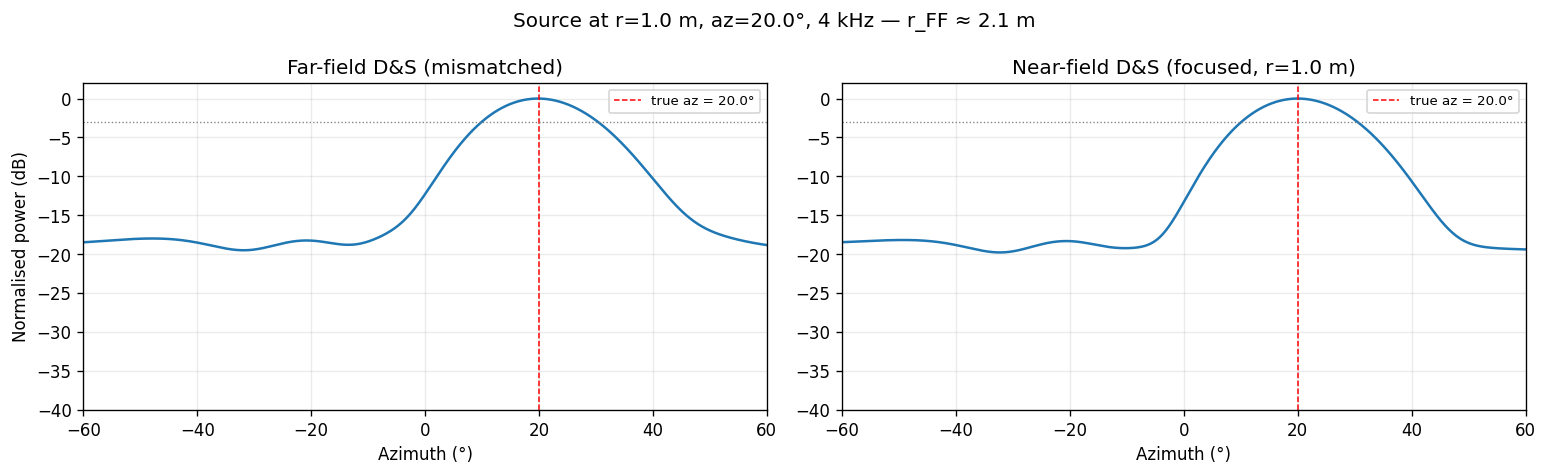

                            Peak (dB)    HPBW (°)   DoA error (°)
Far-field D&S                     0.0        20.3            0.12
Near-field D&S                    0.0        20.3            0.00


In [4]:
freq  = 4000
r_src = 1.0          # source range (m)
az_src = 20.0        # source azimuth (°)
az_grid = np.linspace(-60, 60, 1000)

src_xyz = az_to_xyz(az_src, r_src)
R_nf = make_csm_nf(x_arr, y_arr, [(src_xyz, 1.0)], freq, snr_db=20)

# ── beamformers ───────────────────────────────────────────────────────────────
def ds_1d_ff(x, y, R, freq, az_grid):
    out = np.array([np.real(sv_ff(x, y, az, freq).conj() @ R @ sv_ff(x, y, az, freq))
                    for az in az_grid])
    return out

def ds_1d_nf(x, y, R, freq, az_grid, range_m):
    out = np.array([np.real(sv_nf(x, y, az_to_xyz(az, range_m), freq).conj()
                            @ R @ sv_nf(x, y, az_to_xyz(az, range_m), freq))
                    for az in az_grid])
    return out

map_ff = ds_1d_ff(x_arr, y_arr, R_nf, freq, az_grid)
map_nf = ds_1d_nf(x_arr, y_arr, R_nf, freq, az_grid, r_src)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, label, m in zip(axes, ['Far-field D&S (mismatched)', f'Near-field D&S (focused, r={r_src} m)'],
                               [map_ff, map_nf]):
    ax.plot(az_grid, to_db(m))
    ax.axvline(az_src, color='red', linestyle='--', linewidth=0.9, label=f'true az = {az_src}°')
    ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-60, 60); ax.set_ylim(-40, 2)
    ax.set_title(label); ax.set_xlabel('Azimuth (°)'); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Normalised power (dB)')
fig.suptitle(f'Source at r={r_src} m, az={az_src}°, {freq//1000} kHz — r_FF ≈ 2.1 m')
plt.tight_layout()
plt.savefig('nf_1d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# HPBW
def hpbw(m, az_grid):
    db = to_db(m)
    above = az_grid[db >= -3]
    return (above[-1] - above[0]) if len(above) >= 2 else float('nan')

print(f"{'':25s}  {'Peak (dB)':>10}  {'HPBW (°)':>10}  {'DoA error (°)':>14}")
for label, m in [('Far-field D&S', map_ff), ('Near-field D&S', map_nf)]:
    peak_az = az_grid[np.argmax(m)]
    print(f"{label:25s}  {0.0:>10.1f}  {hpbw(m, az_grid):>10.1f}  {abs(peak_az - az_src):>14.2f}")

## Range Sweep — Where Does Far-Field Break Down?

Sweep source range from 0.3 m to 10 m.  Track:
- **Peak height loss** (mismatch loss of far-field BF relative to near-field BF)
- **HPBW** — how much the main lobe broadens for the mismatched beamformer

The vertical line marks r_FF = 2D²/λ.

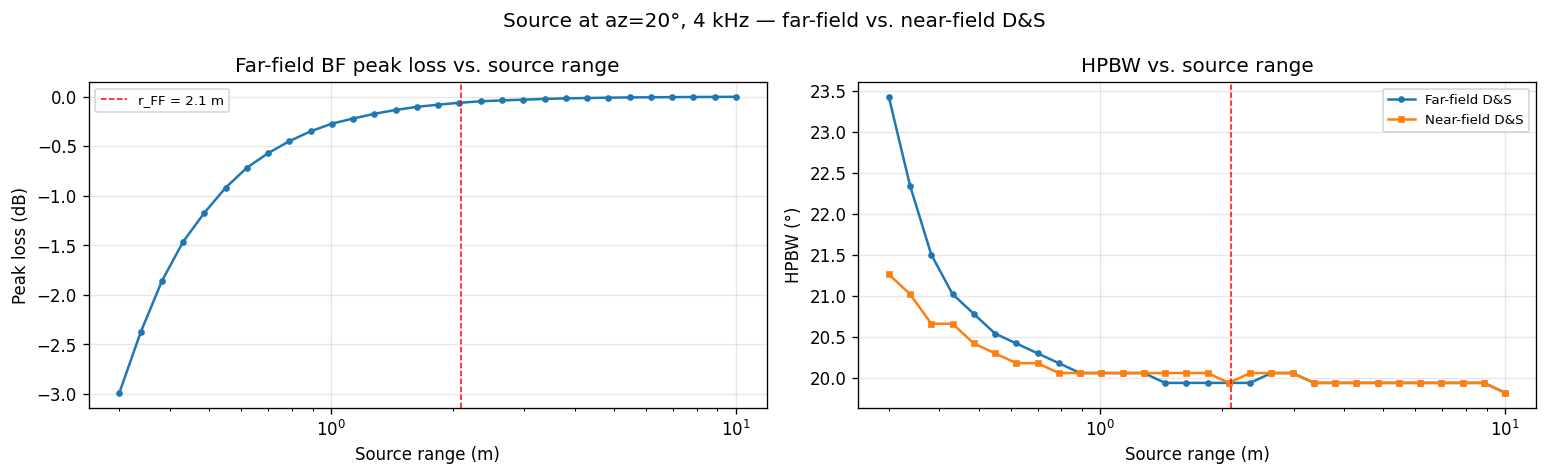

In [5]:
ranges = np.logspace(np.log10(0.3), np.log10(10.0), 30)
r_ff_4k = 2 * D_APERTURE**2 / (C / freq)

peak_loss = []   # dB: 10*log10(P_ff_peak / P_nf_peak)
hpbw_ff   = []
hpbw_nf   = []

for r in ranges:
    xyz = az_to_xyz(20.0, r)
    R   = make_csm_nf(x_arr, y_arr, [(xyz, 1.0)], freq, snr_db=30)
    mff = ds_1d_ff(x_arr, y_arr, R, freq, az_grid)
    mnf = ds_1d_nf(x_arr, y_arr, R, freq, az_grid, r)
    peak_loss.append(10 * np.log10(mff.max() / mnf.max()))
    hpbw_ff.append(hpbw(mff, az_grid))
    hpbw_nf.append(hpbw(mnf, az_grid))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.semilogx(ranges, peak_loss, marker='o', markersize=3)
ax1.axvline(r_ff_4k, color='red', linestyle='--', linewidth=0.9, label=f'r_FF = {r_ff_4k:.1f} m')
ax1.set_xlabel('Source range (m)'); ax1.set_ylabel('Peak loss (dB)')
ax1.set_title('Far-field BF peak loss vs. source range')
ax1.grid(True, alpha=0.3); ax1.legend(fontsize=8)

ax2.semilogx(ranges, hpbw_ff, marker='o', markersize=3, label='Far-field D&S')
ax2.semilogx(ranges, hpbw_nf, marker='s', markersize=3, label='Near-field D&S')
ax2.axvline(r_ff_4k, color='red', linestyle='--', linewidth=0.9)
ax2.set_xlabel('Source range (m)'); ax2.set_ylabel('HPBW (°)')
ax2.set_title('HPBW vs. source range')
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

fig.suptitle(f'Source at az=20°, {freq//1000} kHz — far-field vs. near-field D&S')
plt.tight_layout()
plt.savefig('nf_range_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 2D Focused Map (Range × Azimuth)

Far-field beamforming only estimates direction.  Near-field (focused) beamforming
scans a 2D grid of *(range, azimuth)* and produces an image that estimates
**both range and direction** simultaneously.

The peak of the 2D map is the maximum-likelihood estimate of source position.

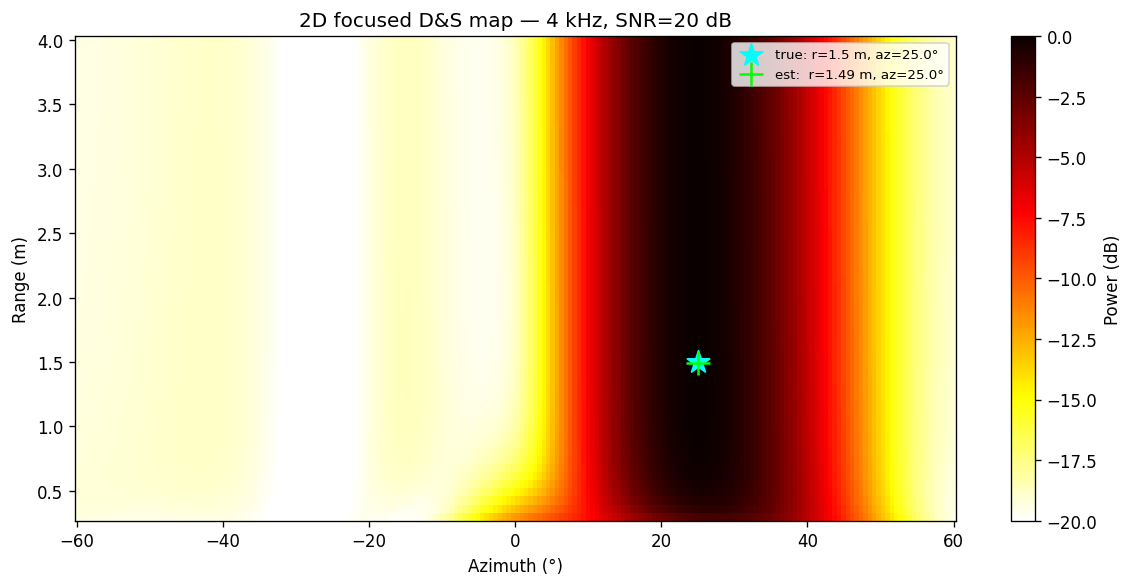

True position:      r = 1.50 m, az = 25.0°
Estimated position: r = 1.49 m, az = 25.0°
Range error:  0.8 cm
Az error:     0.0°


In [6]:
# ── Vectorised 2D focused D&S ─────────────────────────────────────────────────
def focused_map_2d(x, y, R, freq, az_grid, range_grid):
    # Returns P[i_range, i_az] = near-field D&S power.
    # Vectorised: builds steering matrix H then evaluates P = diag(H^H R H).
    N = len(x)
    n_r, n_az = len(range_grid), len(az_grid)
    n_pts = n_r * n_az
    H = np.zeros((N, n_pts), dtype=complex)
    for i, r in enumerate(range_grid):
        for j, az in enumerate(az_grid):
            xs = r * np.sin(np.radians(az))
            zs = r * np.cos(np.radians(az))
            d  = np.sqrt((xs - x)**2 + y**2 + zs**2)
            h  = np.exp(-1j * 2 * np.pi * freq / C * d)
            h /= np.linalg.norm(h)
            H[:, i * n_az + j] = h
    RH = R @ H
    P  = np.real(np.sum(H.conj() * RH, axis=0))
    return P.reshape(n_r, n_az)


# ── Single source at (r=1.5 m, az=25°) ───────────────────────────────────────
r_true, az_true = 1.5, 25.0
xyz_true = az_to_xyz(az_true, r_true)
R_2d = make_csm_nf(x_arr, y_arr, [(xyz_true, 1.0)], freq, snr_db=20)

az_scan    = np.linspace(-60, 60, 200)
range_scan = np.linspace(0.3, 4.0, 60)

P2d = focused_map_2d(x_arr, y_arr, R_2d, freq, az_scan, range_scan)

# Peak estimate
peak_idx   = np.unravel_index(np.argmax(P2d), P2d.shape)
r_est      = range_scan[peak_idx[0]]
az_est     = az_scan[peak_idx[1]]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(az_scan, range_scan, 10 * np.log10(P2d / P2d.max()),
                   cmap='hot_r', vmin=-20, vmax=0, shading='auto')
ax.scatter([az_true], [r_true], marker='*', s=200, color='cyan', zorder=5,
           label=f'true: r={r_true} m, az={az_true}°')
ax.scatter([az_est],  [r_est],  marker='+', s=200, color='lime', linewidths=1.5, zorder=5,
           label=f'est:  r={r_est:.2f} m, az={az_est:.1f}°')
plt.colorbar(im, ax=ax, label='Power (dB)')
ax.set_xlabel('Azimuth (°)'); ax.set_ylabel('Range (m)')
ax.set_title(f'2D focused D&S map — {freq//1000} kHz, SNR=20 dB')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('nf_focused_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True position:      r = {r_true:.2f} m, az = {az_true:.1f}°")
print(f"Estimated position: r = {r_est:.2f} m, az = {az_est:.1f}°")
print(f"Range error:  {abs(r_est - r_true)*100:.1f} cm")
print(f"Az error:     {abs(az_est - az_true):.1f}°")

## 2D Map — Two Near-Field Sources

Two sources at different ranges and azimuths: demonstrates that focused beamforming
separates sources that occupy the same angular direction but different ranges.

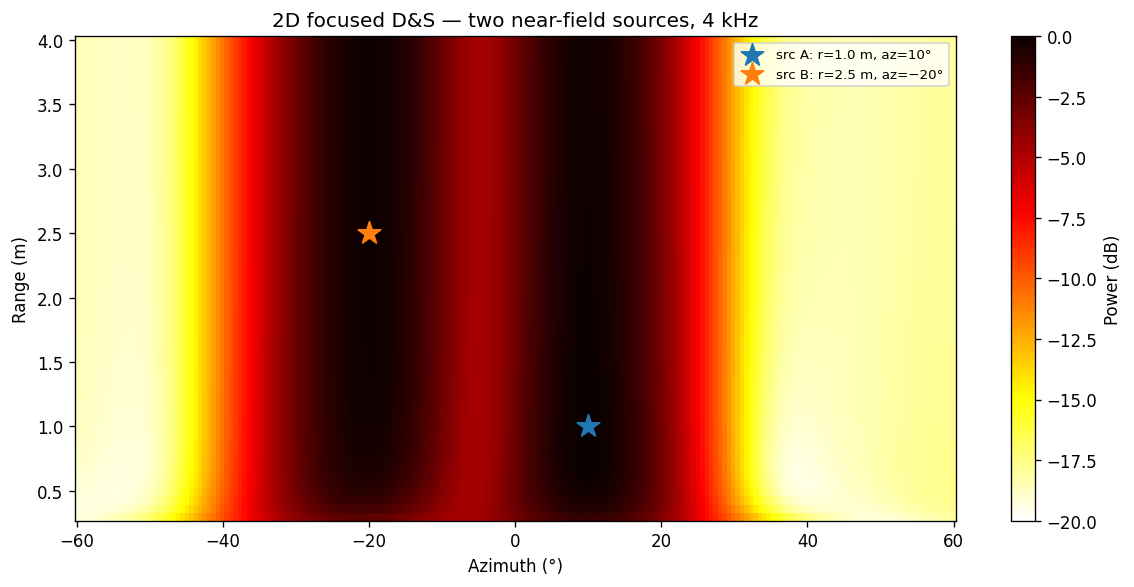

In [7]:
src_a = az_to_xyz(10.0, 1.0)   # 1 m, 10°
src_b = az_to_xyz(-20.0, 2.5)  # 2.5 m, −20°

R_2src = make_csm_nf(x_arr, y_arr, [(src_a, 1.0), (src_b, 1.0)], freq, snr_db=20)
P2d_2src = focused_map_2d(x_arr, y_arr, R_2src, freq, az_scan, range_scan)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(az_scan, range_scan, 10 * np.log10(P2d_2src / P2d_2src.max()),
                   cmap='hot_r', vmin=-20, vmax=0, shading='auto')
for (xs, _, zs), label in [
        (src_a, 'src A: r=1.0 m, az=10°'),
        (src_b, 'src B: r=2.5 m, az=−20°')]:
    az_plot = np.degrees(np.arctan2(xs, zs))
    r_plot  = np.sqrt(xs**2 + zs**2)
    ax.scatter([az_plot], [r_plot], marker='*', s=200, zorder=5, label=label)
plt.colorbar(im, ax=ax, label='Power (dB)')
ax.set_xlabel('Azimuth (°)'); ax.set_ylabel('Range (m)')
ax.set_title(f'2D focused D&S — two near-field sources, {freq//1000} kHz')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('nf_focused_2d_twosrc.png', dpi=150, bbox_inches='tight')
plt.show()

## Algorithm Comparison — Near-Field

Repeat the notebook 03 single-range-slice scenarios using near-field steering.
All beamformers scan azimuth at the true source range (r = 1 m).

In [8]:
def mvdr_1d_nf(x, y, R, freq, az_grid, range_m, diag_load=0.01):
    N = R.shape[0]
    R_inv = inv(R + diag_load * np.trace(R) / N * np.eye(N))
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = sv_nf(x, y, az_to_xyz(az, range_m), freq)
        denom = np.real(h.conj() @ R_inv @ h)
        out[i] = 1.0 / max(denom, 1e-300)
    return out


def music_1d_nf(x, y, R, freq, az_grid, range_m, n_sources):
    _, eigvecs = np.linalg.eigh(R)
    E_n = eigvecs[:, :R.shape[0] - n_sources]
    En_proj = E_n @ E_n.conj().T
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = sv_nf(x, y, az_to_xyz(az, range_m), freq)
        denom = np.real(h.conj() @ En_proj @ h)
        out[i] = 1.0 / max(denom, 1e-300)
    return out


def doa_error_nf(m, az_grid, true_az):
    return abs(az_grid[np.argmax(m)] - true_az)


def two_src_resolved_nf(m, az_grid, az1, az2, threshold_db=-3):
    db = to_db(m)
    lo, hi = sorted([az1, az2])
    between = (az_grid > lo) & (az_grid < hi)
    if not between.any():
        return False
    valley  = db[between].min()
    peak_lo = db[np.argmin(np.abs(az_grid - lo))]
    peak_hi = db[np.argmin(np.abs(az_grid - hi))]
    return valley < min(peak_lo, peak_hi) + threshold_db


r_focus = 1.0  # focus range for all scenarios

_scenarios_nf = [
    ('1: single @ 0°',        [((0.0, 0.0, r_focus), 1.0)],                                     20, 0.0,   None),
    ('2: ±15° (30° sep)',      [(az_to_xyz(-15, r_focus), 1.0), (az_to_xyz(15, r_focus), 1.0)],  20, None, (-15.0, 15.0)),
    ('3: ±4.5° (9° sep)',      [(az_to_xyz(-4.5,r_focus),1.0), (az_to_xyz(4.5,r_focus),1.0)],   20, None, (-4.5, 4.5)),
    ('4: −20 dB weak source',  [(az_to_xyz(-15,r_focus),1.0),(az_to_xyz(10,r_focus),10**(-2))],  30, None, (-15.0, 10.0)),
]

rows = []
az_grid_nf = np.linspace(-60, 60, 1000)
for scenario, sources, snr, true_az, resolve_pair in _scenarios_nf:
    R = make_csm_nf(x_arr, y_arr, sources, freq, snr_db=snr)
    n_src = len(sources)
    maps = {
        'D&S':   ds_1d_nf(x_arr, y_arr, R, freq, az_grid_nf, r_focus),
        'MVDR':  mvdr_1d_nf(x_arr, y_arr, R, freq, az_grid_nf, r_focus),
        'MUSIC': music_1d_nf(x_arr, y_arr, R, freq, az_grid_nf, r_focus, n_src),
    }
    for label, m in maps.items():
        err = round(doa_error_nf(m, az_grid_nf, true_az), 1) if true_az is not None else '—'
        if resolve_pair is not None:
            res = 'Yes' if two_src_resolved_nf(m, az_grid_nf, *resolve_pair) else 'No'
        else:
            res = '—'
        rows.append({'Scenario': scenario, 'Algorithm': label,
                     'DoA error (°)': err, 'Resolved': res})

pd.DataFrame(rows).set_index(['Scenario', 'Algorithm'])

DoA error (°) Resolved
Scenario              Algorithm                       
1: single @ 0°        D&S                 0.1        —
                      MVDR                0.1        —
                      MUSIC               0.1        —
2: ±15° (30° sep)     D&S                   —      Yes
                      MVDR                  —      Yes
                      MUSIC                 —      Yes
3: ±4.5° (9° sep)     D&S                   —       No
                      MVDR                  —       No
                      MUSIC                 —      Yes
4: −20 dB weak source D&S                   —       No
                      MVDR                  —      Yes
                      MUSIC                 —      Yes

## Conclusions

**Near-field correction is necessary below r_FF:**
- At r < r_FF the far-field beamformer's main lobe broadens and peak output drops
  — the mismatch loss is significant even at 2–3× the far-field boundary
- Near-field D&S restores the expected HPBW and peak level by using the correct spherical delays

**Focused beamforming enables range estimation:**
- The 2D focused map (range × azimuth) localises sources in both angle and distance
- Range resolution is coarser than angular resolution (especially at near-boresight angles)
  but provides useful discrimination between sources at the same angle but different depths

**Algorithm behaviour carries over from the far-field study:**
- MVDR and MUSIC retain their dynamic-range and super-resolution advantages when
  using near-field steering vectors — the subspace structure is unchanged
- CLEAN-SC is not included here; it requires adaptation for near-field because it
  subtracts source contributions from the CSM using the steering vector, and the
  near-field version needs the same spherical-wave steering

**Practical implication for Phase 2:**
- The ReSpeaker array (90 mm aperture) has r_FF ≈ 0.05 m at 4 kHz — always far field
  at any practical distance; near-field correction is not needed for Phase 2
- The full 300 mm array requires near-field beamforming at all operating distances
  above ~0.5 kHz and below 2–4 m; the focused formulation developed here is the
  correct baseline for Phase 4